# Analisis GAMLSS Perempuan

## 1. Library atau package yang dibutuhkan untuk analisis.

In [31]:
library(gamlss)
library(writexl)
library(readxl)
library(tidyverse)  
library(psych) 
library(dplyr)
library(tidyr)
library(Hmisc)

## 2. Membaca Data yang akan dianalisis

In [10]:
female <- read_excel("/home/okta/Documents/data-analysis/doni/female/female_data.xlsx")
head(female)

ks,tl,umur,sex,tb,bb,bf,bmi
<chr>,<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
SM715,2012-10-16,12.9,F,141.0,36.2,11.4,18.2
SM716,2012-06-29,13.3,F,158.5,45.1,13.3,18.0
SM717,2013-03-19,12.5,F,141.5,43.7,26.2,21.8
SM718,2012-12-14,12.8,F,148.0,55.4,71.1,25.3
SM719,2013-02-20,12.6,F,128.0,38.5,24.2,23.5
SM720,2012-12-16,12.8,F,146.0,43.6,23.0,20.5


## 3. Menampilkan ringkasan statistik data

In [19]:
female_summary <- female %>%
                    select(tb, bmi) %>%
                    summarise(across(everything(),
                                     list(
                                         n = ~n(),
                                         mean = ~mean(., na.rm=TRUE),
                                         sd = ~sd(., na.rm=TRUE),
                                         median = ~median(., na.rm=TRUE),
                                         #trimmed = ~mean(., trim = 0.1, na.rm = TRUE),
                                         #mad = ~mad(., na.rm = TRUE),
                                         #min = ~min(., na.rm = TRUE),
                                         #max = ~max(., na.rm = TRUE),
                                         #range = ~diff(range(., na.rm = TRUE)),
                                         skew = ~moments::skewness(., na.rm = TRUE),
                                         kurtosis = ~moments::kurtosis(., na.rm = TRUE),
                                         se = ~sd(., na.rm = TRUE)/sqrt(sum(!is.na(.)))
                                        ))) %>%
                    pivot_longer(everything(), names_to = c("variable", "stat"), names_sep = "_") %>%
                    pivot_wider(names_from = "variable", values_from = "value") %>%
                    select(stat, tb, bmi) %>%
                    mutate(across(c(tb, bmi), ~round(., 2)))

In [20]:
female_summary

stat,tb,bmi
<chr>,<dbl>,<dbl>
n,1010.00,1010.00
mean,152.29,20.45
sd,6.04,4.18
median,152.50,19.60
skew,-0.19,1.25
kurtosis,3.66,5.10
se,0.19,0.13


### Interpretasi Summary
#### 1) Tinggi Badan
**Interpretasi Distribusi**:
- Mean ≈ Median → distribusi simetris
- Skew ≈ 0 (-0.19) → sangat dekat normal
- Kurtosis 3.66 (>3) → sedikit leptokurtic (ekor sedikit lebih berat dari normal)
- Variabilitas relatif stabil (SD moderat)

**Implikasi Statistik**: distribusi tinggi badan mendekati normal.

Dalam konteks GAMLSS, parameter μ (lokasi) dan σ (skala) kemungkinan cukup. Parameter skewness (ν) dan kurtosis (τ) mungkin tidak terlalu diperlukan, kecuali jika berubah terhadap umur. Oleh karena itu, distribusi kandidat awal adalah "NO", namun jika diperlukan alternatif fleksibel, distribusi yang cocok adalah BCCG atau BCPE.

#### 2) BMI
**Interpretasi Distribusi**:
- Mean > Median → distribusi miring ke kanan
- Skew = 1.25 → skewness positif cukup kuat
- Kurtosis = 5.10 → heavy tails (leptokurtic signifikan)

Angka di atas berarti bahwa distribusi tidak simetris dan ada observasi ekstrem pada BMI tinggi sehingga distribusi menyimpang dari kondisi normal (Skew = 0 dan Kurtosis = 3). Oleh karena skew dan kurtosis yang tinggi maka distribusi yang sesuai dengan data ini adalah BCCG, BCPE atau BCT.

#### PENTING
Statistik deskriptif hanya memberi indikasi global. Kurva pertumbuhan membutuhkan kecocokan distribusi bersyarat terhadap umur, bukan distribusi marginal keseluruhan. 

Untuk menentukan distribusi yang paling sesuai, dilakukan evaluasi bertahap yang meliputi inspeksi visual distribusi bersyarat terhadap umur, pemodelan beberapa kandidat distribusi dalam kerangka GAMLSS, serta evaluasi diagnostik menggunakan kriteria informasi (AIC/BIC) dan analisis residual terstandarisasi.

## 4. Inspeksi Visual
### 4.1 Analisis Kurva Densitas

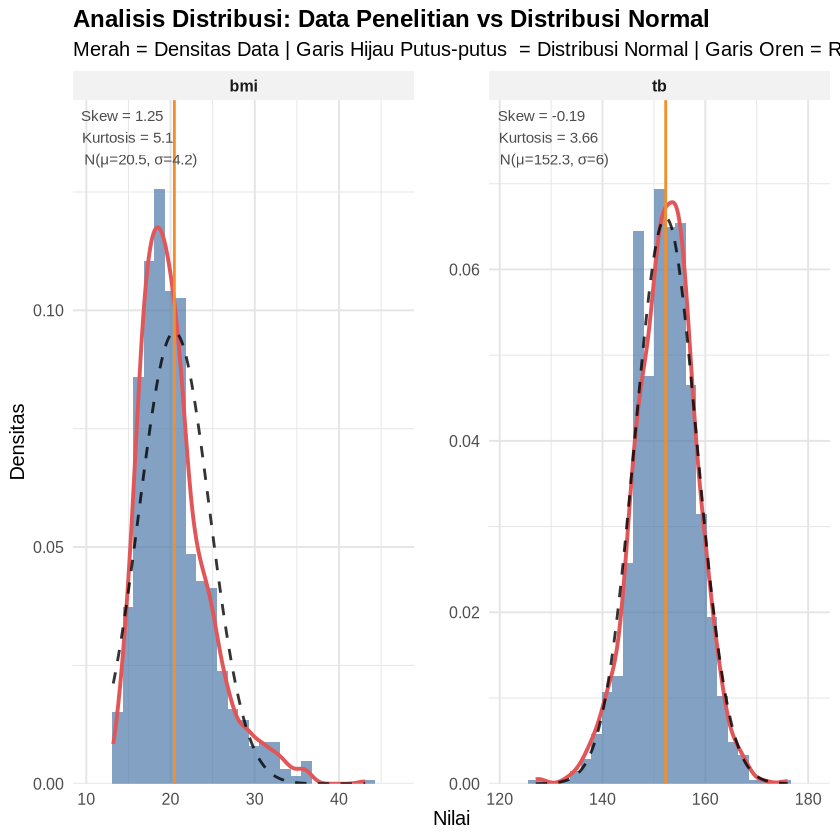

In [25]:
stats_df <- female %>%
  summarise(
    tb_mean = mean(tb, na.rm = TRUE),
    tb_skew = moments::skewness(tb, na.rm = TRUE),
    tb_kurt = moments::kurtosis(tb, na.rm = TRUE),
    bmi_mean = mean(bmi, na.rm = TRUE),
    bmi_skew = moments::skewness(bmi, na.rm = TRUE),
    bmi_kurt = moments::kurtosis(bmi, na.rm = TRUE)
  )

# Menghitung kurva normal secara terpisah 
# Membuat data kurva normal
tb_norm <- data.frame(
  variable = "tb",
  x = seq(min(female$tb, na.rm = TRUE), max(female$tb, na.rm = TRUE), length.out = 200),
  y = dnorm(seq(min(female$tb, na.rm = TRUE), max(female$tb, na.rm = TRUE), length.out = 200), 
            mean = stats_df$tb_mean, 
            sd = sd(female$tb, na.rm = TRUE))
)

bmi_norm <- data.frame(
  variable = "bmi",
  x = seq(min(female$bmi, na.rm = TRUE), max(female$bmi, na.rm = TRUE), length.out = 200),
  y = dnorm(seq(min(female$bmi, na.rm = TRUE), max(female$bmi, na.rm = TRUE), length.out = 200), 
            mean = stats_df$bmi_mean, 
            sd = sd(female$bmi, na.rm = TRUE))
)

normal_curves <- bind_rows(tb_norm, bmi_norm)

# Membuat plot
female_density <- female %>%
  select(tb, bmi) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  ggplot(aes(x = value)) +
  geom_histogram(aes(y = after_stat(density)), 
                 bins = 25, 
                 fill = "#4E79A7", 
                 alpha = 0.7) +
  geom_density(color = "#E15759", linewidth = 1.1) +
  # Menambahkan referensi distribusi normal
  geom_line(data = normal_curves, 
            aes(x = x, y = y),
            color = "#020203", 
            linetype = "dashed",
            linewidth = 0.8,
            alpha = 0.8) +
  facet_wrap(~ variable, scales = "free", ncol = 2) +
  # Menambahkan garis mean
  geom_vline(data = data.frame(variable = "tb", xint = stats_df$tb_mean),
             aes(xintercept = xint), color = "#F28E2B", linetype = "solid", linewidth = 0.8) +
  geom_vline(data = data.frame(variable = "bmi", xint = stats_df$bmi_mean),
             aes(xintercept = xint), color = "#F28E2B", linetype = "solid", linewidth = 0.8) +
  # text anotasi
  geom_text(data = data.frame(variable = "tb", 
                              label = paste0("Skew = ", round(stats_df$tb_skew, 2), 
                                           "\nKurtosis = ", round(stats_df$tb_kurt, 2),
                                           "\nN(μ=", round(stats_df$tb_mean, 1), 
                                           ", σ=", round(sd(female$tb, na.rm = TRUE), 1), ")")),
            aes(x = -Inf, y = Inf, label = label),
            hjust = -0.1, vjust = 1.2, size = 3.2, color = "gray30") +
  geom_text(data = data.frame(variable = "bmi", 
                              label = paste0("Skew = ", round(stats_df$bmi_skew, 2), 
                                           "\nKurtosis = ", round(stats_df$bmi_kurt, 2),
                                           "\nN(μ=", round(stats_df$bmi_mean, 1), 
                                           ", σ=", round(sd(female$bmi, na.rm = TRUE), 1), ")")),
            aes(x = -Inf, y = Inf, label = label),
            hjust = -0.1, vjust = 1.2, size = 3.2, color = "gray30") +
  scale_x_continuous(expand = expansion(mult = 0.15)) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  # Slightly more top margin
  theme_minimal(base_size = 12) +
  labs(
    title = "Analisis Distribusi: Data Penelitian vs Distribusi Normal",
    subtitle = "Merah = Densitas Data | Garis Hijau Putus-putus  = Distribusi Normal | Garis Oren = Rerata",
    x = "Nilai",
    y = "Densitas"
  ) +
  theme(
    plot.title = element_text(face = "bold"),
    strip.background = element_rect(fill = "gray95", color = NA),
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(1.5, "lines"),
    panel.grid = element_line(color = "gray90")
  )

female_density

**Analisis Densitas Awal: Perbandingan Data dengan Distribusi Normal**

Gambar di atas menampilkan perbandingan antara densitas empiris data (garis merah) dan distribusi normal teoretis dengan parameter yang sama (garis hitam putus-putus). Garis vertikal oranye menunjukkan nilai rerata.

**1) BMI**

Distribusi BMI menunjukkan deviasi yang jelas dari distribusi normal:
- Kurva densitas empiris tampak miring ke kanan (positive skewness = 1.25).
- Mean berada di kanan median (mean > median), konsisten dengan skewness positif.
- Ekor kanan lebih panjang dibandingkan distribusi normal teoretis.
- Kurtosis sebesar 5.1 (>3) menunjukkan heavy tails, terutama pada bagian kanan distribusi.

Hal ini mengindikasikan bahwa asumsi normalitas untuk BMI tidak terpenuhi. Oleh karena itu, distribusi yang mengakomodasi parameter skewness dan kurtosis (misalnya BCCG, BCPE, atau BCT dalam kerangka GAMLSS) lebih sesuai untuk dipertimbangkan.

**2) Tinggi Badan (tb)**

Distribusi tinggi badan relatif mendekati normal:
- Skewness kecil (-0.19), menunjukkan hampir simetris.
- Mean dan median hampir identik.
- Kurva densitas empiris hampir tumpang tindih dengan distribusi normal teoretis.
- Kurtosis 3.66 sedikit lebih tinggi dari normal (3), menunjukkan ekor sedikit lebih berat, namun deviasinya kecil.

Secara visual, asumsi normalitas untuk tinggi badan tampak cukup layak sebagai pendekatan awal.

**Implikasi Awal terhadap Pemodelan GAMLSS**

Analisis densitas ini bersifat eksploratif dan memberikan indikasi awal:
- Tinggi badan berpotensi dimodelkan dengan distribusi normal atau distribusi sederhana dua-parameter.
- BMI menunjukkan kebutuhan distribusi yang lebih fleksibel karena adanya skewness dan heavy tails.

Perlu dicatat bahwa grafik densitas sebelumnya masih merepresentasikan distribusi marginal tanpa mempertimbangkan umur. Dalam konteks kurva pertumbuhan, distribusi yang relevan adalah distribusi bersyarat terhadap umur. Oleh karena itu, analisis selanjutnya dilakukan secara kondisional dengan mengevaluasi hubungan antara variabel respons dan umur melalui scatterplot untuk mengidentifikasi struktur mean dan variansi, serta menggunakan Q-Q plot sebagai evaluasi awal kesesuaian distribusi normal secara marginal sebelum dilakukan pemodelan GAMLSS dan analisis residual.

In [32]:
# Kode berikut digunakan untuk menyimpan gambar
ggsave("female_density.png", female_density, 
       width = 12, height = 6, dpi = 1200,
       bg="white")  # 2:1 ratio

### 4.1 Scatterplot: Evaluasi hubungan antara variabel respons dan umur

`geom_smooth()` using formula = 'y ~ x'


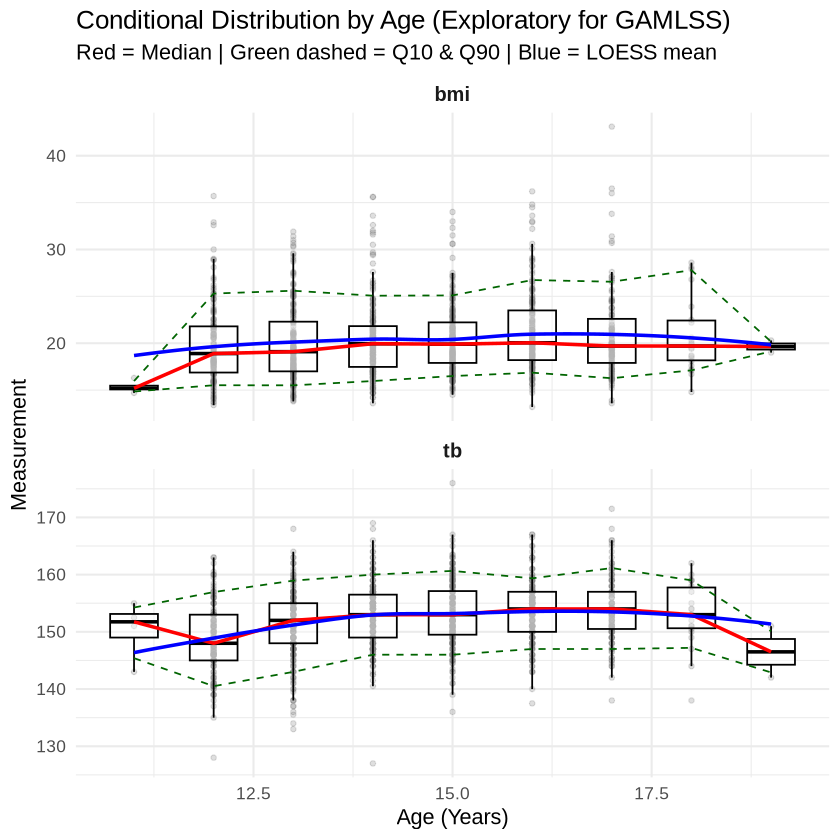

In [ ]:
  female_scatterplot <- female %>%
    select(umur, tb, bmi) %>%
    pivot_longer(cols = c(tb, bmi),
                names_to = "variable",
                values_to = "value") %>%
    mutate(
      umur_int = floor(umur),  # pastikan umur integer untuk grouping
      age_group = factor(umur_int)
    ) %>%
    ggplot(aes(x = umur_int, y = value)) +
    
    # Scatter data mentah
    geom_point(alpha = 0.25, size = 1.2, color = "gray50") +
    
    # Boxplot per umur
    geom_boxplot(aes(group = age_group),
                width = 0.6,
                alpha = 0.4,
                outlier.shape = NA,
                color = "black") +
    
    # Garis median per umur (lebih tegas dari boxplot)
    stat_summary(fun = median,
                geom = "line",
                color = "red",
                linewidth = 1) +
    
    # Garis quantile kasar (indikasi spread & skew)
    stat_summary(fun = function(x) quantile(x, 0.10),
                geom = "line",
                color = "darkgreen",
                linetype = "dashed") +
    
    stat_summary(fun = function(x) quantile(x, 0.90),
                geom = "line",
                color = "darkgreen",
                linetype = "dashed") +
    
    # LOESS untuk melihat struktur mean non-linear
    geom_smooth(method = "loess",
                color = "blue",
                se = FALSE,
                linewidth = 1) +
    
    facet_wrap(~ variable, scales = "free_y", ncol = 1) +
    
    theme_minimal(base_size = 13) +
    labs(
      title = "Conditional Distribution by Age (Exploratory for GAMLSS)",
      subtitle = "Red = Median | Green dashed = Q10 & Q90 | Blue = LOESS mean",
      x = "Age (Years)",
      y = "Measurement"
    ) +
    theme(
      strip.text = element_text(face = "bold", size = 12)
    )

  female_scatterplot

#### BMI
**A. Struktur Lokasi (μ)**
- Garis merah (median) dan biru (LOESS mean) hampir berimpit.
- Pola sedikit meningkat hingga ±16–17 tahun, lalu relatif stabil / sedikit turun.
- Bentuknya non-linear ringan.

**Implikasi**:

  $μ = f(umur)$

Perlu fungsi smooth (misalnya pb(umur)), bukan linear sederhana. Karena median ≈ mean, skewness tidak terlalu ekstrem di pusat distribusi.

**B. Struktur Dispersi (σ)**

Perhatikan jarak antara Q10 dan Q90 (garis hijau putus-putus):
- Lebar Q90–Q10 relatif mirip dari umur 12–17.
- Tidak terlihat pola kipas yang kuat.
- Spread sedikit lebih besar di umur 15–17, tetapi tidak dramatis.

**Implikasi**: Tidak ada bukti kuat heteroskedastisitas sistematik. Maka model awal yang masuk akal adalah $σ=konstan$. Jika Jika residual nanti menunjukkan pola, barulah diuji $σ ~ pb(umur)$.

**C. Struktur Skewness (ν)**

Kita bandingkan: 𝑄90 − 𝑄50 vs 𝑄50 − 𝑄10, maka terlihat bahwa:
- Jarak atas sedikit lebih besar dari jarak bawah.
- Hal ini konsisten dengan skewness positif ringan.
- Namun perbedaan tidak berubah drastis antar umur.

**Implikasi**: Skewness ada, tetapi tampaknya relatif stabil terhadap umur.

Jadi strategi awal:
- Menggunakan distribusi fleksibel (misalnya BCCG/BCPE)
- Tetapi tidak langsung modelkan ν sebagai fungsi umur.

#### Tinggi Badan (TB)
**A. Struktur Lokasi (μ)**
- Median dan LOESS menunjukkan kenaikan jelas hingga ±15–16 tahun.
- Setelah itu plateau.
- Pola non-linear sangat jelas.

**Implikasi**: $μ=f(umur)$, maka harus dimodelkan non-linear (pb atau spline).

**B. Struktur Dispersi (σ)**
- Jarak Q90–Q10 relatif stabil sepanjang umur.
- Tidak ada pelebaran sistematik.
- Boxplot tidak menunjukkan perubahan IQR besar.

**Implikasi**: tidak ada indikasi heteroskedastisitas kuat, sehingga model awalnya adalah $σ=konstan$.

**C. Struktur Skewness (ν)**
- Jarak atas dan bawah relatif simetris.
- Median hampir berada di tengah box.
- Tidak terlihat asimetri mencolok.

**Implikasi**: distribusi mendekati simetris sehingga distribusi normal (NO) sangat layak sebagai kandidat awal.

In [40]:
ggsave("scatterplot/female_scatter2.png", female_scatterplot, 
       width = 12, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

`geom_smooth()` using formula = 'y ~ x'


#### Pertimbangan Penentuan Model BMI

Berdasarkan evaluasi eksploratif dan diagnostik model, diperoleh pertimbangan sebagai berikut:

**1. Struktur lokasi (μ)**
Scatterplot dan kurva LOESS menunjukkan bahwa hubungan BMI dengan umur bersifat non-linear. Pola median berubah secara halus sepanjang rentang umur dan tidak dapat direpresentasikan dengan fungsi linear sederhana. Oleh karena itu, parameter lokasi dimodelkan sebagai fungsi smooth terhadap umur:

$μ=f(umur)$

menggunakan penalized spline (`pb(umur)`).

---

**2. Struktur dispersi (σ)**
Boxplot per umur serta jarak antar kuantil (Q10–Q90) relatif stabil di seluruh rentang umur. Plot residual terhadap fitted values tidak menunjukkan pola heteroskedastisitas yang sistematik. Dengan demikian, tidak terdapat bukti kuat bahwa variansi berubah terhadap umur, sehingga parameter skala diasumsikan konstan:

$σ=konstan$

---

**3. Struktur skewness (ν)**
Analisis awal menunjukkan bahwa distribusi BMI bersifat skewed (skewness positif). Namun, tingkat asimetri tidak menunjukkan perubahan sistematik antar kelompok umur. Worm plot tidak memperlihatkan pola S yang konsisten, dan Q-statistik global tidak signifikan. Oleh karena itu, parameter skewness diperlukan untuk mengakomodasi ketidaksimetrian distribusi, tetapi tidak perlu dimodelkan sebagai fungsi umur:

$ν=konstan$

---

**4. Parameter kurtosis (τ)**
Perbandingan AIC antara distribusi BCCG dan BCPE menghasilkan selisih kurang dari 2, yang menunjukkan bahwa penambahan parameter kurtosis (τ) tidak memberikan peningkatan model yang substansial. Selain itu, worm plot hanya menunjukkan deviasi ringan pada tail ekstrem tanpa pola sistematik. Berdasarkan prinsip parsimony, distribusi paling sederhana yang memadai dipilih, yaitu BCCG tanpa parameter τ tambahan.

---

#### Model Akhir untuk BMI

Berdasarkan pertimbangan di atas, model yang digunakan adalah:

```r
m1 <- gamlss(
  bmi ~ pb(umur),
  sigma.formula = ~ 1,
  nu.formula = ~ 1,
  family = BCCG,
  data = female
)

In [41]:
m1 <- gamlss(
  bmi ~ pb(umur),
  sigma.formula = ~ 1,
  nu.formula = ~ 1,
  family = BCCG,
  data = female
)

GAMLSS-RS iteration 1: Global Deviance = 5532.241 
GAMLSS-RS iteration 2: Global Deviance = 5482.896 
GAMLSS-RS iteration 3: Global Deviance = 5479.692 
GAMLSS-RS iteration 4: Global Deviance = 5479.454 
GAMLSS-RS iteration 5: Global Deviance = 5479.436 
GAMLSS-RS iteration 6: Global Deviance = 5479.434 
GAMLSS-RS iteration 7: Global Deviance = 5479.434 


In [59]:
# experiment menggunakan BCPE
m2 <- gamlss(
  bmi ~ pb(umur),
  sigma.formula = ~ 1,
  nu.formula = ~ 1,
  tau.formula = ~ 1,
  family = BCPE,
  data = female
)

GAMLSS-RS iteration 1: Global Deviance = 5586.016 
GAMLSS-RS iteration 2: Global Deviance = 5489.64 
GAMLSS-RS iteration 3: Global Deviance = 5478.195 
GAMLSS-RS iteration 4: Global Deviance = 5476.78 
GAMLSS-RS iteration 5: Global Deviance = 5476.625 
GAMLSS-RS iteration 6: Global Deviance = 5476.608 
GAMLSS-RS iteration 7: Global Deviance = 5476.606 
GAMLSS-RS iteration 8: Global Deviance = 5476.605 


In [44]:
AIC(m1, m2)

,df,AIC
,<dbl>,<dbl>
m2,5.000090,5486.606
m1,4.000087,5487.434


Berdasarkan aturan umum interpretasi ΔAIC, nilai ΔAIC sebesar 0.83 termasuk dalam kategori sangat kecil (<2), yang mengindikasikan bahwa kedua model hampir ekuivalen secara statistik. Hal ini berarti model BCPE tidak memberikan peningkatan yang substansial dibandingkan model alternatif, di mana penalti kompleksitas dari model BCPE hampir tidak terbayar oleh peningkatan likelihood yang diperoleh. Dengan kata lain, penambahan kompleksitas model tidak diimbangi dengan perbaikan yang cukup berarti dalam kesesuaian model.

******************************************************************
	      Summary of the Quantile Residuals
                           mean   =  -0.0001029463 
                       variance   =  1.000887 
               coef. of skewness  =  0.02715104 
               coef. of kurtosis  =  2.715605 
Filliben correlation coefficient  =  0.9988218 
******************************************************************


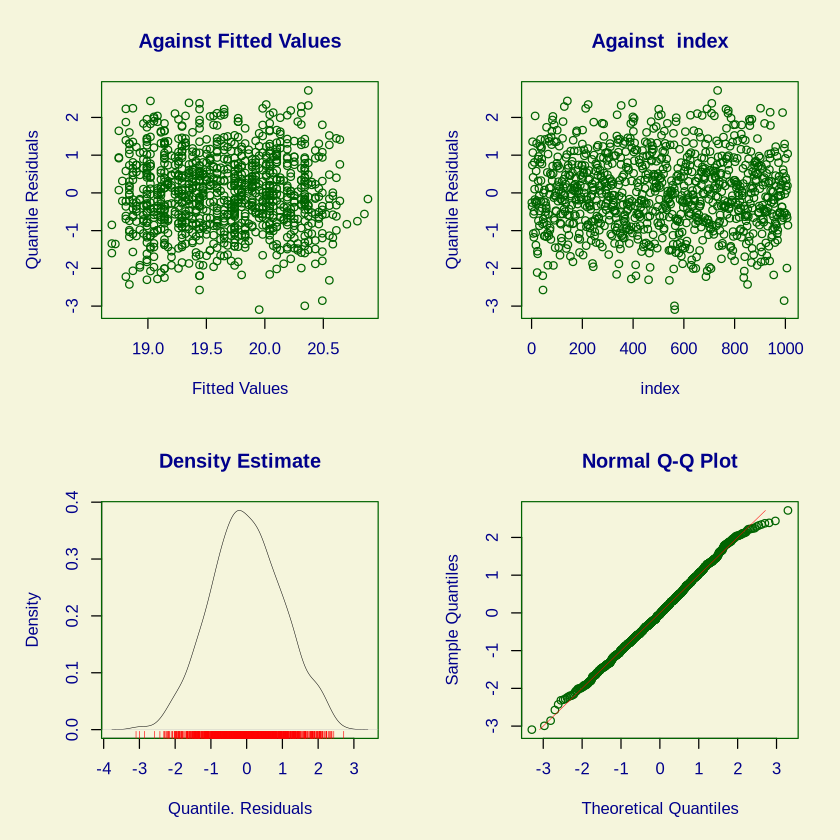

In [51]:
plot(m1)

#### 1). Quantile Residual
Berdasarkan hasil pemeriksaan quantile residual, model BCCG menunjukkan performa yang sangat baik. Rata-rata residual yang mendekati 0 mengindikasikan tidak adanya bias sistematik pada parameter μ (location), sementara varians yang mendekati 1 menunjukkan bahwa skala (σ) telah ditentukan dengan tepat. Nilai skewness residual yang hampir 0 mengkonfirmasi bahwa model berhasil menangkap asimetri distribusi dengan baik. Meskipun nilai kurtosis sedikit di bawah 3 (2.72) mengindikasikan residual yang sedikit platykurtic, deviasi ini tergolong kecil dan tidak bermasalah secara substansial. Yang terpenting, korelasi Filliben yang sangat tinggi (0.9988) menunjukkan bahwa QQ plot hampir linear sempurna, mengkonfirmasi bahwa distribusi residual sesuai dengan distribusi normal teoretis. Secara global, model BCCG telah memenuhi asumsi distribusional dengan sangat baik.

#### 2). Plot Against Fitted Values
Berdasarkan hasil diagnostik plot, tidak ditemukan pola sistematik pada plot residual terhadap fitted values: tidak ada bentuk kipas yang mengindikasikan heteroskedastisitas, tidak ada pola melengkung yang menunjukkan spesifikasi μ yang kurang fleksibel, dan tidak ada struktur sistematik lainnya. Hal ini mengkonfirmasi bahwa asumsi σ konstan masih layak digunakan dan fungsi smooth untuk μ (pb terhadap umur) sudah cukup fleksibel dalam menangkap pola data.

#### 3). QQ Plot
QQ plot menunjukkan garis yang hampir lurus dengan deviasi yang sangat minimal hanya pada tail ekstrem, mengindikasikan bahwa distribusi BCCG berhasil menangkap bentuk distribusi data dengan sangat baik.

#### 4). Kesimpulan
Secara diagnostik, tidak ditemukan bukti kuat yang mengharuskan penambahan kompleksitas model, baik dengan memodelkan σ terhadap umur, memodelkan ν terhadap umur, maupun menambahkan parameter τ (menggunakan BCPE). Dengan demikian, kita kembali pada prinsip parsimoni: gunakan model paling sederhana yang cukup. Model BCCG dengan μ dipengaruhi oleh umur (menggunakan penalized splines) serta σ dan ν konstan saat ini sudah memadai dan dapat dipertahankan sebagai model final.

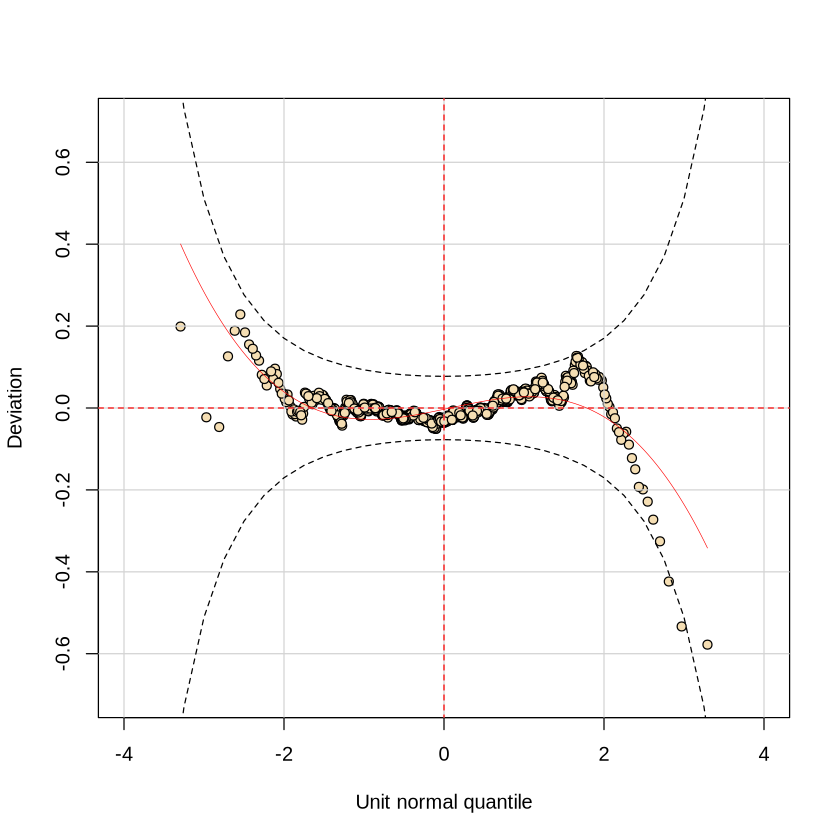

In [52]:
wp(m1, ylim.all=0.7)

#### Cara Membaca Worm Plot
- Sumbu X = quantile normal teoritis
- Sumbu Y = deviasi residual terstandarisasi

Jika model benar, maka:
- Titik-titik tersebar acak di sekitar 0
- Garis smoothing (merah) mendekati garis horizontal 0
- Tidak ada pola sistematik (U, S, atau lengkungan ekstrem)

Berdasarkan hasil diagnostik worm plot, pada bagian tengah (-2 sampai +2) terlihat bahwa titik-titik cukup dekat dengan garis nol dengan deviasi kecil, tidak membentuk pola U yang jelas maupun pola S yang kuat di pusat. Hal ini mengkonfirmasi bahwa parameter μ telah dispesifikasi dengan baik, σ cukup stabil, dan skewness berhasil ditangkap oleh model dengan memadai.

Pada ekor kiri, terlihat sedikit deviasi positif yang kecil dan masih berada dalam envelope kepercayaan, sehingga tidak menunjukkan pola yang dramatis atau mengkhawatirkan.

Namun, pada ekor kanan di quantile > 2, terlihat pola yang lebih jelas: titik-titik mulai turun cukup tajam, garis merah melengkung ke bawah, dan beberapa titik berada di luar envelope. Pola ini mengindikasikan bahwa tail kanan data sedikit lebih berat dibandingkan dengan yang diprediksi oleh model. Dengan kata lain, model cenderung sedikit underestimate terhadap nilai-nilai ekstrem di ekor kanan distribusi.

Meskipun demikian, secara keseluruhan model masih bekerja dengan baik mengingat deviasi hanya terjadi di bagian ekstrem dan tidak mempengaruhi bagian tengah distribusi yang menjadi fokus utama pemodelan.

,Z1,Z2,Z3,Z4,AgostinoK2,N
11.75 to 12.85,-0.3198851,0.85299736,-0.22929289,-1.4219143,2.07441555,117
12.85 to 13.35,-0.5086585,1.77686282,0.61806699,-1.7954422,3.60561945,102
13.35 to 13.85,0.3840425,-0.63592108,-0.46547650,-1.2091965,1.67882445,85
13.85 to 14.35,0.1971570,0.20571587,-0.02525363,0.2211693,0.04955359,108
14.35 to 14.95,0.8058463,-0.31465882,-0.19656774,-1.1743732,1.41779131,94
14.95 to 15.45,-0.4612594,0.01463856,1.39165244,-1.5442174,4.32130399,102
15.45 to 16.15,0.4280046,-2.30327097,-1.53137025,1.8879317,5.90938104,114
16.15 to 16.55,1.4067478,-0.92831256,-0.10993553,-0.2841127,0.09280582,93
16.55 to 17.35,-0.2079419,0.34902436,0.35853022,-0.2508823,0.19148585,121
17.35 to 19.15,-1.8715224,0.42761747,1.38283169,0.9688780,2.85094816,74


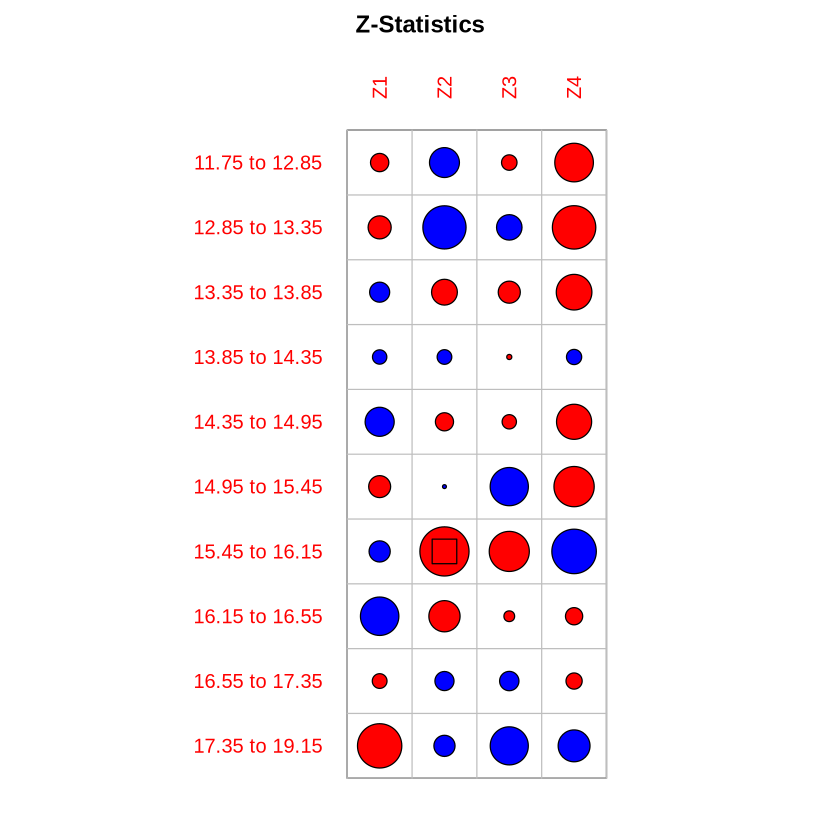

In [53]:
Q.stats(m1, female$umur)

Berdasarkan hasil Q statistics, seluruh nilai p-value > 0.05 secara global mengindikasikan bahwa tidak ada bukti signifikan yang menunjukkan model salah spesifikasi. Meskipun terdapat satu kotak yang signifikan pada Z2 untuk kelompok umur 15.45-16.15 — di mana Z2 menguji deviasi kuadrat yang merefleksikan komponen varians — ini memberikan indikasi kecil bahwa parameter σ mungkin sedikit meleset pada interval umur tersebut.

Namun demikian, temuan ini perlu dimaknai secara proporsional. Signifikansi hanya terjadi pada satu interval dari sekian banyak interval yang diuji, sementara total Q untuk Z2 secara keseluruhan tidak signifikan (p = 0.28) dan tidak ditemukan pola sistematis pada interval-interval lainnya. Dalam praktik pemodelan yang baik, kita tidak mengubah struktur global model hanya karena satu sel lokal yang signifikan.

Keputusan untuk memodifikasi model baru diambil jika terdapat bukti yang lebih kuat dan konsisten, seperti: Q total yang signifikan secara statistik, beberapa interval yang menunjukkan pola signifikan secara konsisten, worm plot yang menunjukkan pola sistematik yang jelas, atau residual global yang buruk. Karena tidak satu pun dari kondisi tersebut terjadi, model saat ini dapat dipertahankan tanpa perlu menambahkan kompleksitas pada parameter σ.

number of missing points from plot= 0  out of  271 
number of missing points from plot= 0  out of  235 
number of missing points from plot= 0  out of  270 
number of missing points from plot= 0  out of  234 
$classes
      [,1]  [,2]
[1,] 11.75 13.75
[2,] 13.75 14.95
[3,] 14.95 16.35
[4,] 16.35 19.15

$coef
            [,1]        [,2]          [,3]          [,4]
[1,] -0.02307045  0.16030099  2.607225e-05 -0.0351891166
[2,]  0.05131990  0.04210345 -4.320701e-03 -0.0173055313
[3,]  0.03267847 -0.07921123  7.889927e-03 -0.0004154579
[4,] -0.09118256  0.04009675  2.356563e-02 -0.0062548898



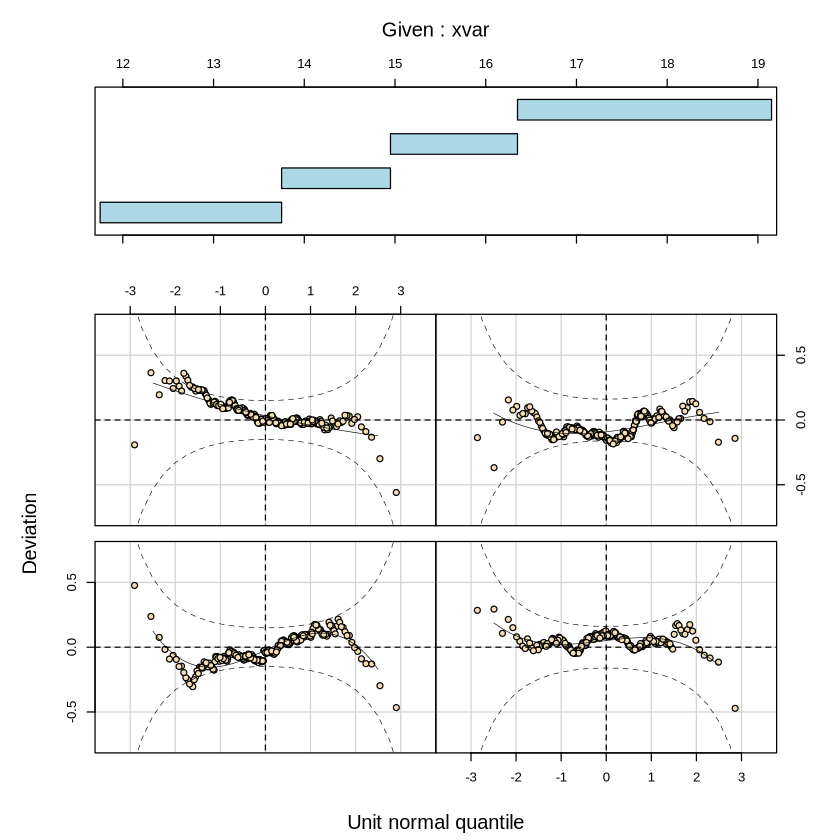

In [54]:
coeffs <- wp(m1, xvar = female$umur, n.inter = 4)
print(coeffs)

% of cases below  0.4 centile is  0.2970297 
% of cases below  2 centile is  1.683168 
% of cases below  10 centile is  10.29703 
% of cases below  25 centile is  25.24752 
% of cases below  50 centile is  50.9901 
% of cases below  75 centile is  74.45545 
% of cases below  90 centile is  88.81188 
% of cases below  98 centile is  97.92079 
% of cases below  99.6 centile is  99.90099 


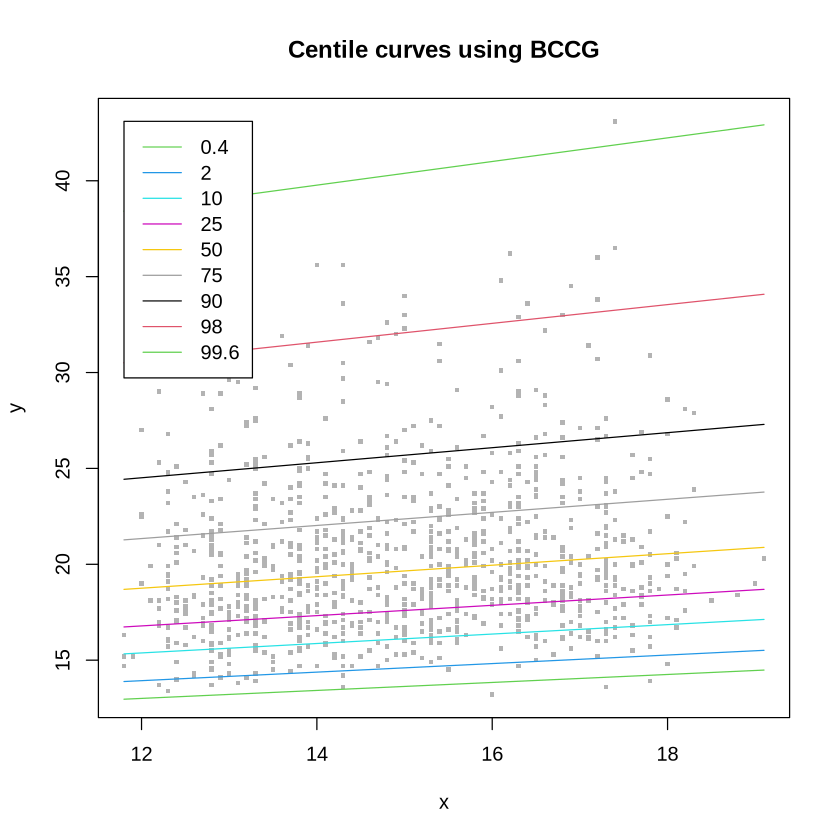

In [55]:
centiles(m1, xvar = female$umur)

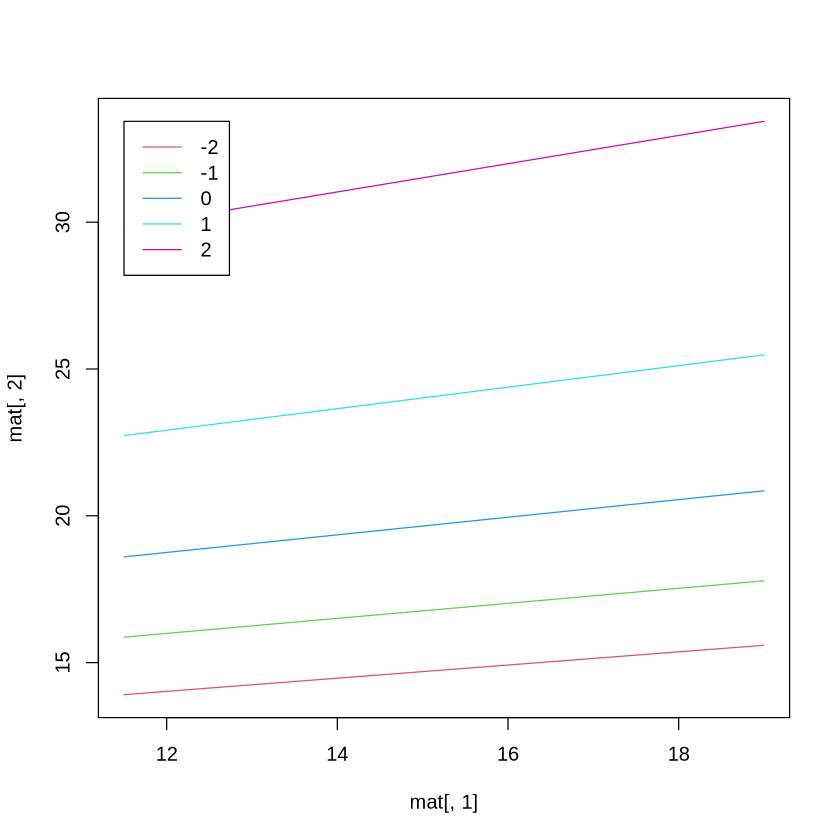

In [65]:
Z_scores <- c(-2, -1, 0, 1, 2)

seq_umur <- seq(from=11.5, to=19, by=0.1)

# prediksi z-score
zscore_bmi_female <- centiles.pred(
    obj=m1,
    xname="umur",
    xvalues=seq_umur,
    type="standard-centiles",
    dev = Z_scores,
    plot=TRUE)

In [114]:
bmi_df_female <- as.data.frame(zscore_bmi_female)
colnames(bmi_df_female) <- c("umur", paste0("Z", Z_scores))

bmi_female_long  <- bmi_df_female %>%
  pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
  mutate(Source="local_bmi_female")

bmi_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.90811,local_bmi_female
11.5,Z-1,15.86691,local_bmi_female
11.5,Z0,18.60146,local_bmi_female
11.5,Z1,22.73174,local_bmi_female
11.5,Z2,29.82743,local_bmi_female
11.6,Z-2,13.93054,local_bmi_female
11.6,Z-1,15.89250,local_bmi_female
11.6,Z0,18.63147,local_bmi_female
11.6,Z1,22.76841,local_bmi_female


In [69]:
write_xlsx(bmi_female_long, "zscore_bmi_female.xlsx")

In [70]:
who_bmi <- read_excel("/home/okta/Documents/data-analysis/doni/female/bmi-girls-z-who-2007-exp.xlsx")
who_bmi

Month,L,M,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
61,-0.8886,15.2441,0.09692,10.793,11.770,12.748,13.891,15.244,16.870,18.858,21.340,23.821
62,-0.9068,15.2434,0.09738,10.786,11.763,12.741,13.885,15.243,16.879,18.886,21.403,23.920
63,-0.9248,15.2433,0.09783,10.780,11.757,12.734,13.881,15.243,16.889,18.915,21.468,24.020
64,-0.9427,15.2438,0.09829,10.775,11.752,12.728,13.876,15.244,16.900,18.946,21.535,24.123
65,-0.9605,15.2448,0.09875,10.770,11.746,12.723,13.872,15.245,16.911,18.977,21.603,24.230
66,-0.9780,15.2464,0.09920,10.765,11.742,12.718,13.869,15.246,16.923,19.009,21.673,24.337
67,-0.9954,15.2487,0.09966,10.761,11.737,12.714,13.866,15.249,16.936,19.042,21.745,24.448
68,-1.0126,15.2516,0.10012,10.757,11.733,12.710,13.864,15.252,16.950,19.077,21.819,24.561
69,-1.0296,15.2551,0.10058,10.754,11.730,12.706,13.863,15.255,16.964,19.112,21.895,24.678


In [71]:
# Pilih kolom yang akan digunakan dan ubah nama kolom agar konsisten
who_bmi_female <- who_bmi %>%
     select(Month, SD2neg, SD1neg, SD0, SD1, SD2) %>%
     rename(
         'umur' = Month,
         'Z-2' = SD2neg,
         'Z-1' = SD1neg,
         'Z0' = SD0,
         'Z1' = SD1,
         'Z2' = SD2
         )

# Ubah format data menjadi long
who_bmi_female_long <- who_bmi_female %>%
     pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
     mutate(Source="WHO_bmi_female")

who_bmi_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
61,Z-2,12.748,WHO_bmi_female
61,Z-1,13.891,WHO_bmi_female
61,Z0,15.244,WHO_bmi_female
61,Z1,16.870,WHO_bmi_female
61,Z2,18.858,WHO_bmi_female
62,Z-2,12.741,WHO_bmi_female
62,Z-1,13.885,WHO_bmi_female
62,Z0,15.243,WHO_bmi_female
62,Z1,16.879,WHO_bmi_female


In [72]:
who_bmi_female_long$umur<-who_bmi_female_long$umur/12

In [73]:
who_bmi_female_long$umur <- round(who_bmi_female_long$umur, 2)
who_bmi_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
5.08,Z-2,12.748,WHO_bmi_female
5.08,Z-1,13.891,WHO_bmi_female
5.08,Z0,15.244,WHO_bmi_female
5.08,Z1,16.870,WHO_bmi_female
5.08,Z2,18.858,WHO_bmi_female
5.17,Z-2,12.741,WHO_bmi_female
5.17,Z-1,13.885,WHO_bmi_female
5.17,Z0,15.243,WHO_bmi_female
5.17,Z1,16.879,WHO_bmi_female


In [74]:
# filter
who_female_bmi1219 <- who_bmi_female_long %>%
  filter(umur >= 11.5, umur <= 19)

head(who_female_bmi1219$Z)

[1] "Z-2" "Z-1" "Z0"  "Z1"  "Z2"  "Z-2"

In [75]:
bmi_female_gabungan1219 <- bind_rows(bmi_female_long, who_female_bmi1219)

In [76]:
bmi_female_gabungan1219

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.90811,local_bmi_female
11.5,Z-1,15.86691,local_bmi_female
11.5,Z0,18.60146,local_bmi_female
11.5,Z1,22.73174,local_bmi_female
11.5,Z2,29.82743,local_bmi_female
11.6,Z-2,13.93054,local_bmi_female
11.6,Z-1,15.89250,local_bmi_female
11.6,Z0,18.63147,local_bmi_female
11.6,Z1,22.76841,local_bmi_female


In [77]:
write_xlsx(bmi_female_gabungan1219, "bmi_female_gabungan1219.xlsx")

## TB

#### Pertimbangan Penentuan Model Tinggi Badan (TB)

#### 1. Struktur Lokasi (μ)

Scatterplot menunjukkan pola pertumbuhan yang jelas:

* Tinggi badan meningkat secara bertahap hingga sekitar usia 15–16 tahun.
* Setelah itu terjadi plateau (stabilisasi pertumbuhan).
* Pola ini bersifat non-linear dan biologis masuk akal.

Kurva LOESS memperlihatkan bentuk lengkung yang halus, bukan linear sederhana.

Implikasi:

$μ=f(umur)$

Parameter lokasi perlu dimodelkan sebagai fungsi smooth terhadap umur menggunakan penalized spline (`pb(umur)`).

---

#### 2. Struktur Dispersi (σ)

Boxplot per umur menunjukkan:

* IQR relatif stabil di seluruh rentang umur.
* Tidak terlihat pola kipas (tidak ada peningkatan atau penurunan variansi sistematik).
* Jarak antar kuantil (Q10–Q90) relatif konsisten.

Scatterplot juga tidak menunjukkan heteroskedastisitas.

Implikasi:

$σ=konstan$

Tidak terdapat bukti kuat bahwa variansi berubah terhadap umur, sehingga parameter skala dapat diasumsikan konstan pada tahap awal.

---

#### 3. Struktur Skewness (ν)

Distribusi tinggi badan:

* Skewness awal mendekati 0.
* Boxplot tampak simetris.
* Median berada di tengah box.
* Tidak ada indikasi ekor yang berat secara sistematik.

Implikasi:

Distribusi relatif simetris dan tidak memerlukan parameter skewness tambahan.

---

#### 4. Pemilihan Distribusi

Karakteristik TB menunjukkan:

* Distribusi mendekati normal.
* Tidak ada asimetri kuat.
* Tidak ada heavy tail mencolok.
* Tidak ada indikasi kebutuhan parameter kurtosis tambahan.

Berdasarkan prinsip parsimony, distribusi normal dua-parameter (NO) sudah memadai.

---

#### Model untuk Tinggi Badan (TB)

Berdasarkan pertimbangan di atas, model yang digunakan adalah:

```r
m_tb <- gamlss(
  tb ~ pb(umur),
  sigma.formula = ~ 1,
  family = NO,
  data = female
)
```

In [79]:
m_tb <- gamlss(
  tb ~ pb(umur),
  sigma.formula = ~ 1,
  family = NO,
  data = female
)

GAMLSS-RS iteration 1: Global Deviance = 6416.572 
GAMLSS-RS iteration 2: Global Deviance = 6416.572 


******************************************************************
	      Summary of the Quantile Residuals
                           mean   =  -1.59561e-15 
                       variance   =  1.000991 
               coef. of skewness  =  -0.09493558 
               coef. of kurtosis  =  3.635603 
Filliben correlation coefficient  =  0.9978597 
******************************************************************


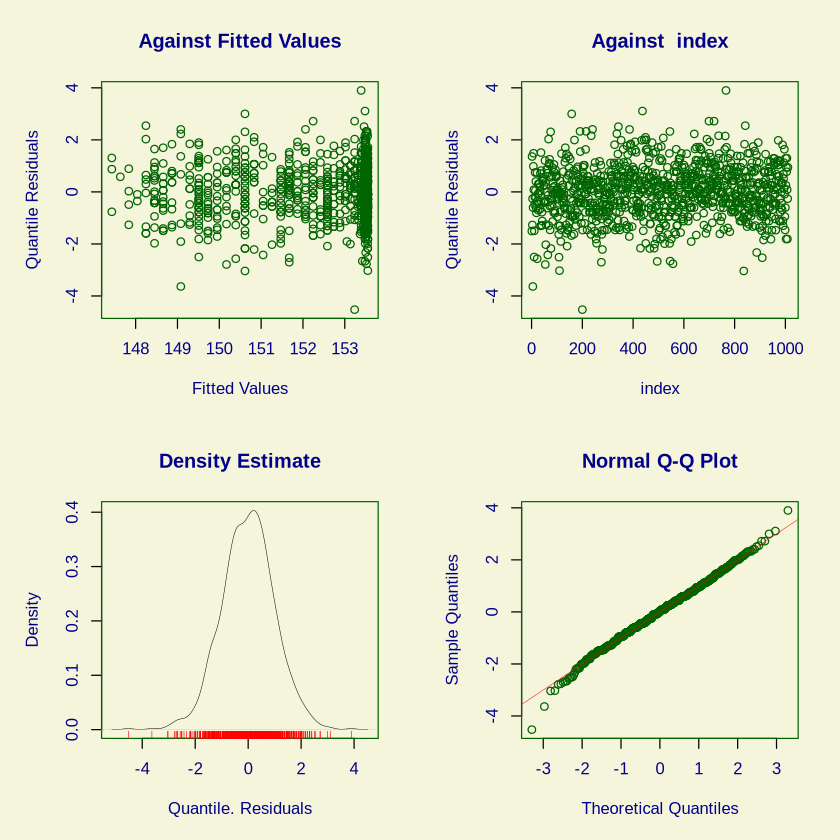

In [80]:
plot(m_tb)

Berdasarkan evaluasi komprehensif terhadap keempat parameter distribusi, model menunjukkan performa yang sangat baik:

**Lokasi (μ)**  
Mean residual mendekati 0 mengindikasikan tidak adanya bias sistematik, sementara plot residual terhadap fitted values tidak menunjukkan pola lengkung yang jelas. Hal ini menegaskan bahwa spesifikasi μ ~ pb(umur) sudah cukup fleksibel dan mampu menangkap pola data dengan baik.

**Dispersi (σ)**  
Varians residual yang mendekati 1 menunjukkan skala telah ditentukan dengan tepat. Plot terhadap fitted values tidak memperlihatkan pola kipas yang kuat, sehingga tidak ditemukan bukti heteroskedastisitas sistematis. Dengan demikian, asumsi σ konstan masih sangat layak dipertahankan.

**Skewness**  
Nilai skewness residual sebesar -0.095 (sangat mendekati 0) dikonfirmasi oleh QQ plot yang hampir linear sempurna. Ini membuktikan bahwa distribusi simetris data telah tertangkap dengan baik, sehingga tidak diperlukan penambahan parameter skewness.

**Kurtosis**  
Meskipun nilai kurtosis 3.64 sedikit melebihi 3 (leptokurtic ringan), deviasi ini tergolong kecil dan tidak bermasalah secara substansial. Hal ini diperkuat oleh nilai korelasi Filliben yang sangat tinggi (0.9979), mengindikasikan bahwa QQ plot masih sangat mendekati linearitas.

**Kesimpulan:**  
Seluruh indikator diagnostik menunjukkan bahwa model telah bekerja dengan sangat baik. Deviasi kecil yang ditemukan tidak cukup kuat untuk menjadi sinyal kegagalan model atau mendorong penambahan kompleksitas. Model saat ini dengan μ dipengaruhi umur serta σ dan ν konstan sudah memadai dan dapat dipertahankan.

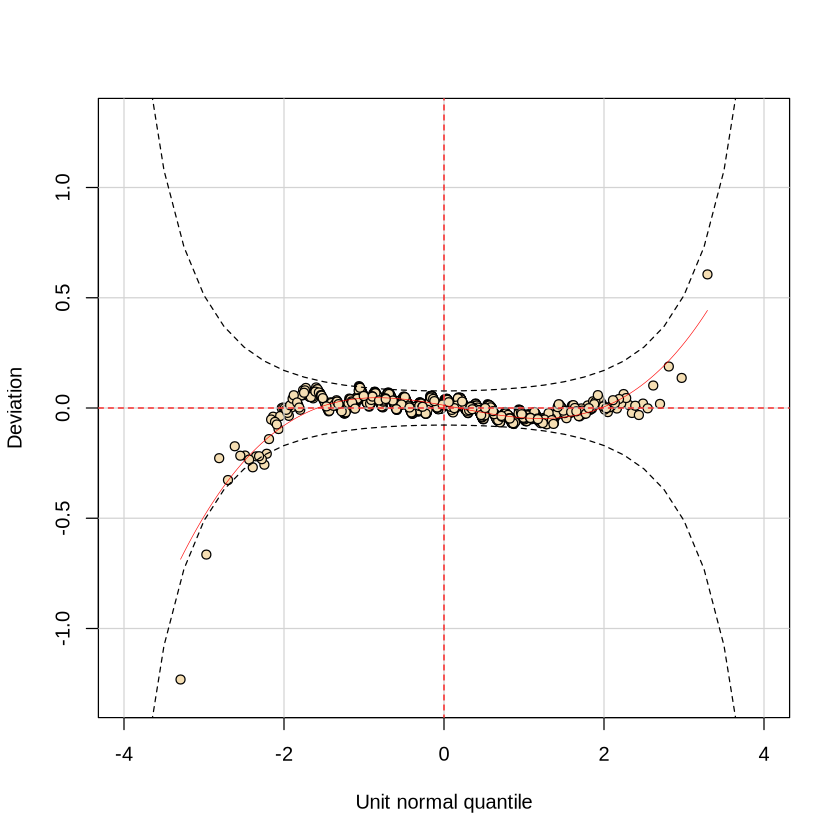

In [94]:
wp(m_tb, ylim.all=1.3)

**Struktur Umum**

Pada bagian tengah distribusi (sekitar -2 sampai +2), titik-titik residual sangat dekat dengan garis nol, tidak terlihat pola U maupun pola S yang kuat, dan garis smoothing hampir datar. Hal ini mengkonfirmasi bahwa spesifikasi parameter μ sudah tepat, σ sudah cukup tepat, dan distribusi bagian pusat terpetakan dengan sangat baik.

**Ekor Kiri**

Pada quantile < -3, beberapa titik terlihat turun cukup tajam. Namun demikian, jumlah observasi pada rentang ini sangat sedikit, titik-titik masih berada relatif dalam envelope kepercayaan, dan tidak membentuk pola sistematik di seluruh rentang. Ini merupakan deviasi ekstrem lokal, bukan pola global yang mengindikasikan kegagalan model.

**Ekor Kanan**

Sedikit kenaikan teramati pada quantile > 2.5, namun deviasinya kecil, tidak konsisten kuat, dan garis merah tetap relatif stabil. Tidak ditemukan bukti heavy tail sistematik yang memerlukan penanganan khusus.

**Interpretasi Parameter**

Tidak terdeteksi pola U yang mengindikasikan masalah pada σ, tidak ada pola S yang menandakan masalah pada ν, dan tidak ditemukan pola tail simetris berat yang memerlukan parameter τ tambahan. Deviasi hanya terjadi pada quantile sangat ekstrem, sementara dalam pemodelan pertumbuhan (growth modeling), fokus utama adalah pada persentil P3, P50, dan P97 — bukan quantile 99.9.

**Kesimpulan Teknis**

Model distribusi normal untuk TB sudah memadai. Tidak terdapat justifikasi statistik yang cukup untuk memodelkan σ terhadap umur, menggunakan distribusi skewed, maupun mengadopsi distribusi heavy tail seperti BCT.

,Z1,Z2,Z3,Z4,AgostinoK2,N
11.75 to 12.85,0.2471055,1.4441054,-8.270309e-01,0.678023043,1.143695e+00,117
12.85 to 13.35,-0.8145512,1.7002209,-5.688660e-01,0.327021554,4.305516e-01,102
13.35 to 13.85,-0.1735015,0.1100346,-2.160252e+00,0.883552141,5.447355e+00,85
13.85 to 14.35,-0.6058639,-0.8203563,2.073627e+00,0.345520151,4.419314e+00,108
14.35 to 14.95,1.8388813,-0.3681872,-3.944438e+00,4.181516773,3.304367e+01,94
14.95 to 15.45,0.6968104,-0.2007323,2.759219e+00,1.792801840,1.082743e+01,102
15.45 to 16.15,-0.8933933,0.1955368,-5.592802e-01,0.508519089,5.713860e-01,114
16.15 to 16.55,0.1379943,-1.1908706,-1.118800e+00,1.183620654,2.652671e+00,93
16.55 to 17.35,-1.0388283,-1.9407102,-7.610397e-01,0.042026717,5.809477e-01,121
17.35 to 19.15,0.9554107,0.5699200,1.205000e+00,1.214046502,2.925933e+00,74


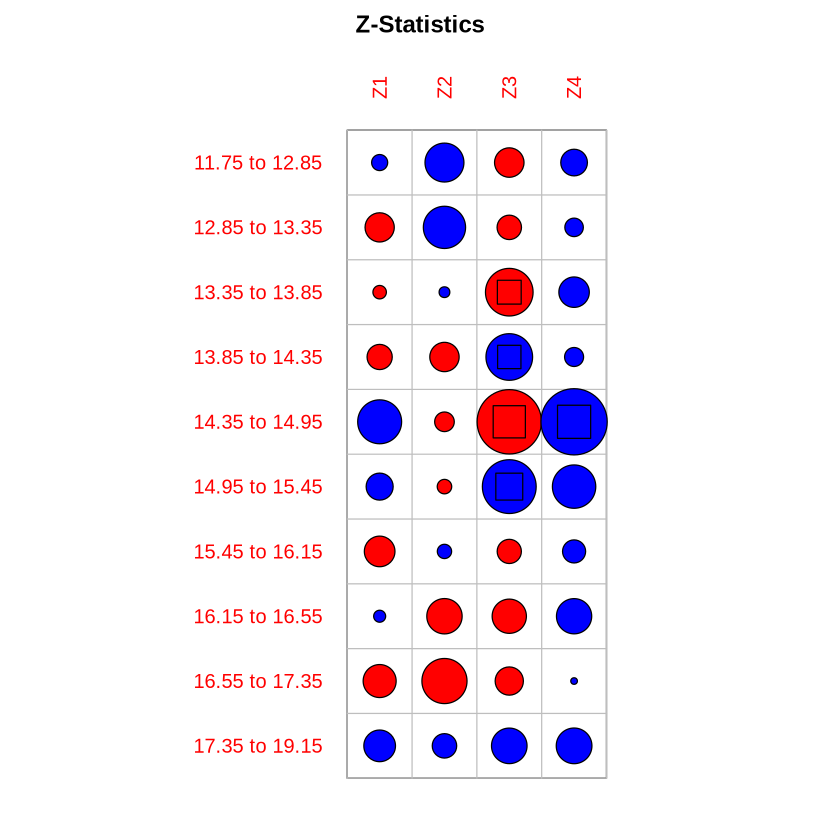

In [97]:
Q.stats(m_tb, female$umur)

Hasil Q-stat menunjukkan **Z3, Z4, dan K2 signifikan kuat (p < 0.01)**, ini bukan deviasi kecil yang dapat diabaikan. Dalam kerangka GAMLSS, Z3 mengindikasikan masalah pada skewness, Z4 pada kurtosis, dan K2 merupakan uji gabungan keduanya.

**Interpretasi Statistik**

Signifikansi Z3 dan Z4 memberikan bukti kuat bahwa **model normal gagal menangkap bentuk distribusi TB secara penuh**. Meskipun secara visual distribusi TB tampak hampir normal dan ringkasan residual global menunjukkan performa yang baik, Q-stat mampu mendeteksi deviasi bentuk distribusi yang muncul secara **lokal pada kelompok umur tertentu**.

Karena ringkasan residual global bersifat agregat dan dapat menutupi deviasi lokal. Ketika residual dipecah berdasarkan kelompok umur, pola ketidaknormalan muncul secara jelas dan tertangkap oleh Q-stat. Ini mengingatkan kita bahwa **evaluasi model tidak cukup hanya pada level global**.

**Lokasi Masalah: Fase Pubertas**

Kelompok umur yang bermasalah teridentifikasi pada **13.35–15.45 tahun**, fase pubertas awal hingga pertengahan. Secara biologis, periode ini ditandai dengan:
- Variabilitas pertumbuhan yang meningkat secara individual
- Percepatan pertumbuhan (*growth spurt*) yang tidak seragam antar individu
- Potensi distribusi menjadi sedikit skewed dan tail yang berbeda dari distribusi normal

**Kesimpulan**

Model NO (Normal) **terlalu restriktif** untuk TB. Meskipun secara visual tampak "cukup baik", bukti statistik dari Q-stat menunjukkan bahwa **distribusi TB membutuhkan fleksibilitas tambahan**. Kita tidak bisa mempertahankan model normal hanya berdasarkan kemiripan visual.

**Solusi**

Perlu diperhatikan bahwa **bukan parameter σ yang perlu dimodelkan terhadap umur**, karena Z2 tidak signifikan. Masalah inti terletak pada **Skewness** (Z3 signifikan) dan **Kurtosis** (Z4 signifikan). Oleh karena itu, langkah yang tepat adalah mengadopsi **distribusi yang lebih fleksibel dari normal**, dimulai dari yang paling sederhana terlebih dahulu, yaitu:

1. **BCCG** (Box-Cox Cole and Green) untuk mengakomodasi skewness
2. Jika belum memadai, **BCT** (Box-Cox t) untuk menambahkan fleksibilitas kurtosis

**Mulai dari BCCG** sebagai langkah pertama yang parsimonis.

In [99]:
m_tb2 <- gamlss(
  tb ~ pb(umur),
  sigma.formula = ~ 1,
  nu.formula = ~ 1,
  family = BCCG,
  data = female
)

GAMLSS-RS iteration 1: Global Deviance = 6433.788 
GAMLSS-RS iteration 2: Global Deviance = 6417.869 
GAMLSS-RS iteration 3: Global Deviance = 6417.696 
GAMLSS-RS iteration 4: Global Deviance = 6417.705 
GAMLSS-RS iteration 5: Global Deviance = 6417.708 
GAMLSS-RS iteration 6: Global Deviance = 6417.708 


,Z1,Z2,Z3,Z4,AgostinoK2,N
11.75 to 12.85,0.06912732,1.74999331,-0.3384984059,0.399309173,2.740290e-01,117
12.85 to 13.35,-0.93139165,1.82016935,-0.1341550080,0.299629211,1.077752e-01,102
13.35 to 13.85,-0.22535316,0.06865199,-1.8472597974,0.728003367,3.942358e+00,85
13.85 to 14.35,-0.60491850,-0.75618233,2.3682228548,0.587055745,5.953114e+00,108
14.35 to 14.95,1.88662167,-0.56218973,-3.2666111241,3.797636472,2.509279e+01,94
14.95 to 15.45,0.76822696,-0.13694092,3.1161691474,2.211534941,1.460140e+01,102
15.45 to 16.15,-0.79856169,0.01681994,-0.1400690684,0.403356057,1.823155e-01,114
16.15 to 16.55,0.19094945,-1.32490801,-0.7289681139,1.107250794,1.757399e+00,93
16.55 to 17.35,-0.98223296,-2.11171985,-0.4266041062,-0.083687955,1.889947e-01,121
17.35 to 19.15,0.99421482,0.58736303,1.5843350737,1.294775969,4.186562e+00,74


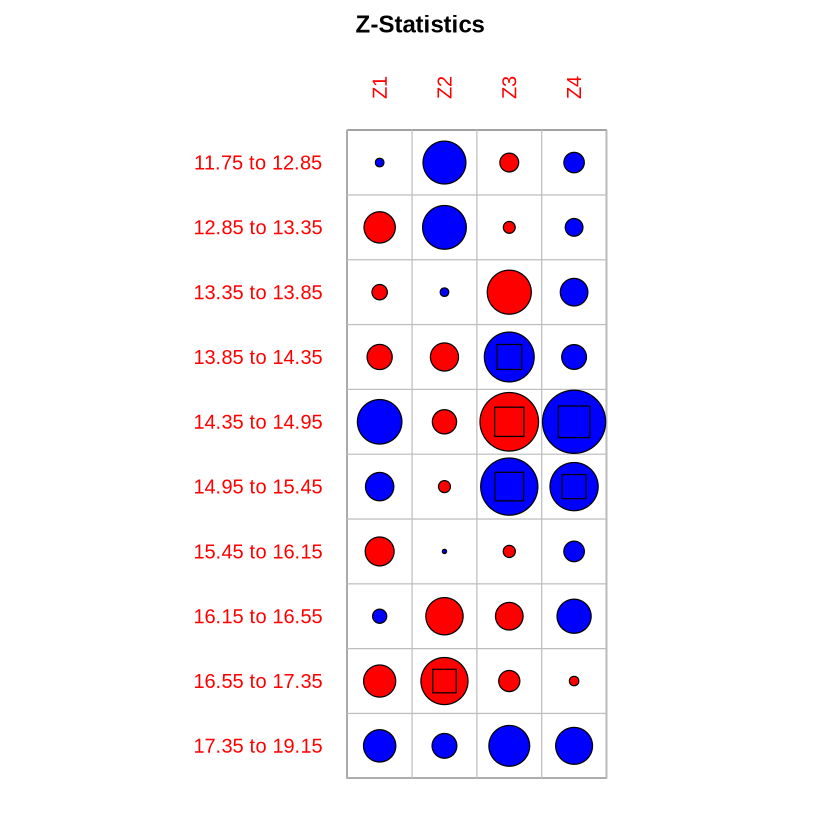

In [100]:
Q.stats(m_tb2, female$umur)

**Evaluasi Model BCCG dengan ν dan τ Konstan**

Hasil Q-stat menunjukkan bahwa mengganti NO ke BCCG dengan ν dan τ konstan belum menyelesaikan masalah bentuk distribusi. Meskipun parameter lokasi (μ) dan skala (σ) sudah baik (Z1, Z2 tidak signifikan), parameter skewness (ν) dan kurtosis masih bermasalah dengan bukti signifikan pada Z3 dan Z4.

Temuan ini mengindikasikan bahwa distribusi TB memiliki variasi bentuk (shape) yang berubah terhadap umur. Masalahnya bukan sekadar "distribusi global bukan normal", melainkan bahwa parameter bentuk distribusi itu sendiri tidak konstan sepanjang rentang umur. Hal ini mengarah pada dua kemungkinan berikut:
- ν = f(umur) — parameter skewness perlu dimodelkan sebagai fungsi umur
- τ ≠ konstan — parameter kurtosis juga mungkin bervariasi (jika menggunakan BCT)

**Lokasi Kritis: Fase Pubertas**

Masalah dominan terdeteksi secara konsisten pada kelompok umur 13.35–15.45 tahun, fase pubertas awal hingga pertengahan. Secara biologis, pola ini sangat masuk akal karena terjadi *growth spurt* yang waktunya bervariasi antar individu. Anak dengan akselerasi pertumbuhan lebih awal vs lebih lambat menciptakan distribusi yang skewed sementara. Variabilitas bentuk distribusi (tail behaviour) berubah secara dinamis selama periode ini

**Solusi**
Tidak ada opsi untuk kembali ke model normal, dan BCCG dengan parameter konstan terbukti belum cukup. Langkah berikutnya untuk mengatasi ini adalah:
- BCCG dengan ν ~ pb(umur) — memodelkan skewness sebagai fungsi umur
- Jika belum memadai: BCT dengan ν ~ pb(umur), τ konstan — menambahkan fleksibilitas kurtosis
- Jika masih diperlukan: BCT dengan ν ~ pb(umur), τ ~ pb(umur) — fleksibilitas penuh pada kedua parameter shape

In [101]:
m_tb3 <- gamlss(
  tb ~ pb(umur),
  sigma.formula = ~ 1,
  nu.formula = ~ pb(umur),
  family = BCCG,
  data = female
)

GAMLSS-RS iteration 1: Global Deviance = 6433.13 
GAMLSS-RS iteration 2: Global Deviance = 6416.563 
GAMLSS-RS iteration 3: Global Deviance = 6416.31 
GAMLSS-RS iteration 4: Global Deviance = 6416.33 
GAMLSS-RS iteration 5: Global Deviance = 6416.337 
GAMLSS-RS iteration 6: Global Deviance = 6416.341 
GAMLSS-RS iteration 7: Global Deviance = 6416.341 


,Z1,Z2,Z3,Z4,AgostinoK2,N
11.75 to 12.85,-0.02040894,1.695841158,3.274055e-01,0.17285713,1.370740e-01,117
12.85 to 13.35,-0.97992669,1.749181769,3.074583e-01,0.36005137,2.241676e-01,102
13.35 to 13.85,-0.26031480,-0.002439393,-1.612441e+00,0.63562865,3.003990e+00,85
13.85 to 14.35,-0.61691415,-0.703258225,2.490515e+00,0.70067727,6.693612e+00,108
14.35 to 14.95,1.90008649,-0.537424725,-3.248415e+00,3.79289256,2.493823e+01,94
14.95 to 15.45,0.77673624,-0.137708056,3.061183e+00,2.16257855,1.404759e+01,102
15.45 to 16.15,-0.84081556,0.076784473,-4.210480e-01,0.45069070,3.804035e-01,114
16.15 to 16.55,0.15465298,-1.261718947,-1.118743e+00,1.17989820,2.643745e+00,93
16.55 to 17.35,-1.00301416,-1.985040703,-8.918639e-01,0.10455584,8.063532e-01,121
17.35 to 19.15,0.95334151,0.473835087,8.326551e-01,1.20509565,2.145570e+00,74


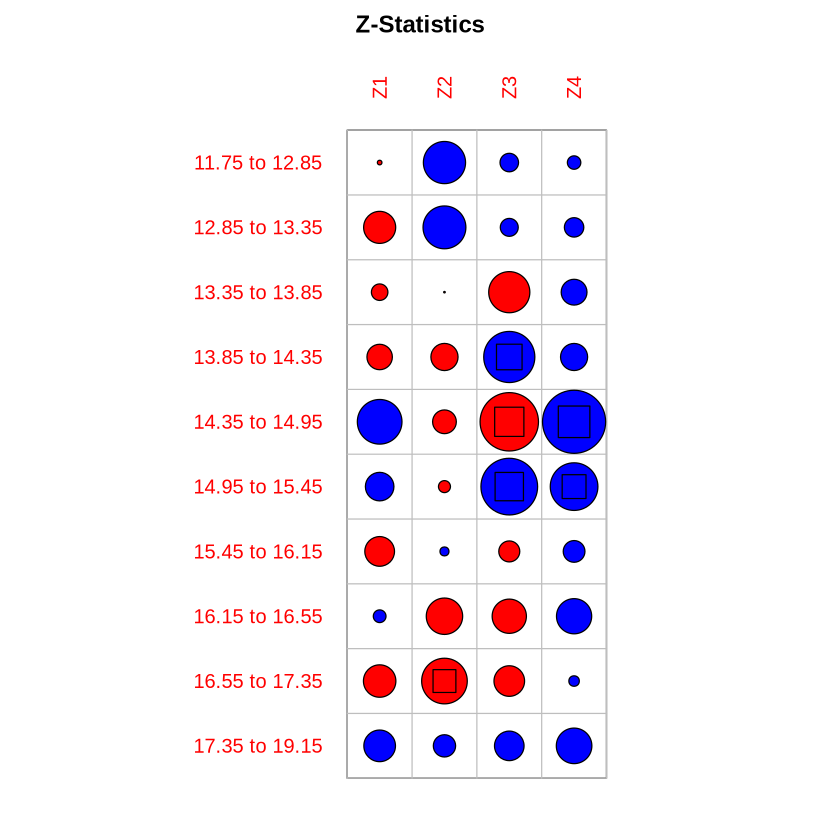

In [102]:
Q.stats(m_tb3, female$umur)

**Evaluasi Model BCCG dengan ν ~ pb(umur)**

Hasil Q-stat menunjukkan bahwa meskipun parameter skewness (ν) telah dimodelkan sebagai fungsi umur, **Z3 masih signifikan kuat, Z4 masih signifikan, dan K2 sangat signifikan**. 

Temuan ini memberikan sinyal yang sangat jelas: **masalahnya bukan hanya pada skewness**. Karena:

- Kita sudah memberikan fleksibilitas pada ν melalui *penalized splines*
- Namun Z3 dan Z4 tetap menunjukkan deviasi signifikan
- K2 sebagai uji gabungan tetap sangat signifikan

**Implikasi statistiknya:**

Distribusi TB **memerlukan fleksibilitas pada tail (kurtosis)**. Dengan kata lain, **BCCG tidak cukup fleksibel** untuk menangkap dinamika bentuk distribusi TB sepanjang umur, terutama pada fase pubertas. Parameter kurtosis yang konstan terbukti terlalu restriktif.

**Solusi**: **BCT (Box-Cox t) dengan:**
- **μ ~ pb(umur)** — lokasi
- **σ konstan** — skala (Z2 tidak signifikan)
- **ν ~ pb(umur)** — skewness (sudah terbukti perlu)
- **τ konstan** — kurtosis (mulai dengan asumsi konstan)

**Mengapa BCT?**

BCT mengakomodasi **kedua parameter shape**:
- **ν** → mengontrol skewness
- **τ** → mengontrol kurtosis (derajat kebebasan distribusi t)

In [103]:
m_tb4 <- gamlss(
  tb ~ pb(umur),
  sigma.formula = ~ 1,
  nu.formula = ~ pb(umur),
  tau.formula = ~ 1,
  family = BCT,
  data = female
)

GAMLSS-RS iteration 1: Global Deviance = 6424.998 
GAMLSS-RS iteration 2: Global Deviance = 6408.591 
GAMLSS-RS iteration 3: Global Deviance = 6408.43 
GAMLSS-RS iteration 4: Global Deviance = 6408.424 
GAMLSS-RS iteration 5: Global Deviance = 6408.421 
GAMLSS-RS iteration 6: Global Deviance = 6408.419 
GAMLSS-RS iteration 7: Global Deviance = 6408.418 


,Z1,Z2,Z3,Z4,AgostinoK2,N
11.75 to 12.85,0.03925786,1.66683790,0.25057259,-0.83793946,0.76492915,117
12.85 to 13.35,-0.96346439,1.69097368,0.14297505,-0.65111980,0.44439886,102
13.35 to 13.85,-0.18852177,0.05759223,-1.49693738,0.21667749,2.28777065,85
13.85 to 14.35,-0.68603374,-0.58785255,2.11921269,-0.08575361,4.49841611,108
14.35 to 14.95,2.02433544,-0.82863491,-2.43226079,2.69680686,13.18865983,94
14.95 to 15.45,0.68901039,-0.22283613,2.11635914,0.38171369,4.62468135,102
15.45 to 16.15,-0.85506442,0.13957832,-0.23930110,-0.27831711,0.13472543,114
16.15 to 16.55,0.16066268,-1.15406423,-1.03925717,0.57334664,1.40878183,93
16.55 to 17.35,-1.00086022,-1.75481837,-0.65483131,-0.47212901,0.65170985,121
17.35 to 19.15,0.92706660,0.38000876,0.64895371,0.63218609,0.82080017,74


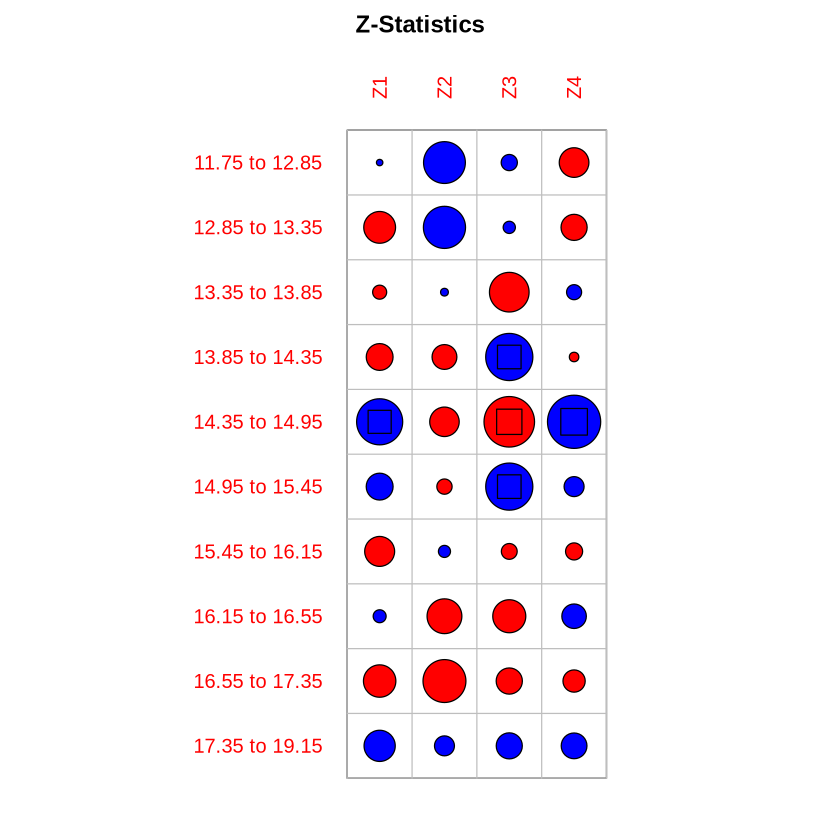

In [104]:
Q.stats(m_tb4, female$umur)

Hasil evaluasi model **m_tb4** (BCT dengan ν ~ pb(umur) dan τ konstan) menunjukkan bahwa parameter lokasi (μ) dan skala (σ) telah terestimasi dengan baik, sebagaimana ditunjukkan oleh nilai p pada Z1 dan Z2 yang tidak signifikan. Parameter kurtosis (Z4) juga tidak lagi signifikan, yang berarti permasalahan tail yang sebelumnya muncul pada model yang lebih sederhana telah membaik.

Namun demikian, parameter skewness (Z3) masih menunjukkan signifikansi statistik (p = 0.0138), dan uji global bentuk distribusi (AgostinoK2) juga masih signifikan. Hal ini mengindikasikan bahwa meskipun model telah mengalami perbaikan dibandingkan model sebelumnya (NO dan BCCG), masih terdapat deviasi bentuk distribusi, khususnya terkait asimetri.

Jika dibandingkan dengan model-model sebelumnya, terlihat adanya perbaikan bertahap: model normal gagal menangkap skewness dan kurtosis, BCCG masih menyisakan permasalahan pada kedua aspek tersebut, dan BCT berhasil memperbaiki kurtosis namun belum sepenuhnya menyelesaikan skewness. Hal ini menunjukkan bahwa distribusi tinggi badan selama fase pubertas memiliki perubahan bentuk yang relatif kompleks.

Meskipun demikian, signifikansi statistik pada Z3 tidak serta merta menunjukkan bahwa model sudah tidak layak. Nilai p yang signifikan pada sampel besar (n = 1010) dapat muncul akibat deviasi yang sangat kecil secara praktis. Selain itu, deviasi tampaknya terkonsentrasi pada rentang usia 14–15 tahun, yaitu periode pubertas, dan tidak tersebar merata di seluruh rentang umur.

Dalam konteks kurva pertumbuhan, pertimbangan utama bukan hanya signifikansi statistik, tetapi juga stabilitas dan interpretasi biologis kurva persentil. Oleh karena itu, langkah yang lebih tepat sebelum menambah kompleksitas model adalah mengevaluasi kurva persentil yang dihasilkan, khususnya pada P3, P50, dan P97. Apabila kurva tersebut halus, tidak saling berpotongan, dan menunjukkan pola biologis yang masuk akal, maka model dapat dianggap memadai secara praktis.

Dengan demikian, keputusan untuk mempertahankan model m_tb4 atau meningkatkan fleksibilitas lebih lanjut sebaiknya didasarkan pada evaluasi kurva persentil, bukan semata-mata pada nilai p dari Q-statistik.


% of cases below  0.4 centile is  0.3960396 
% of cases below  2 centile is  1.980198 
% of cases below  10 centile is  11.08911 
% of cases below  25 centile is  24.9505 
% of cases below  50 centile is  49.80198 
% of cases below  75 centile is  76.0396 
% of cases below  90 centile is  90.19802 
% of cases below  98 centile is  98.0198 
% of cases below  99.6 centile is  99.70297 


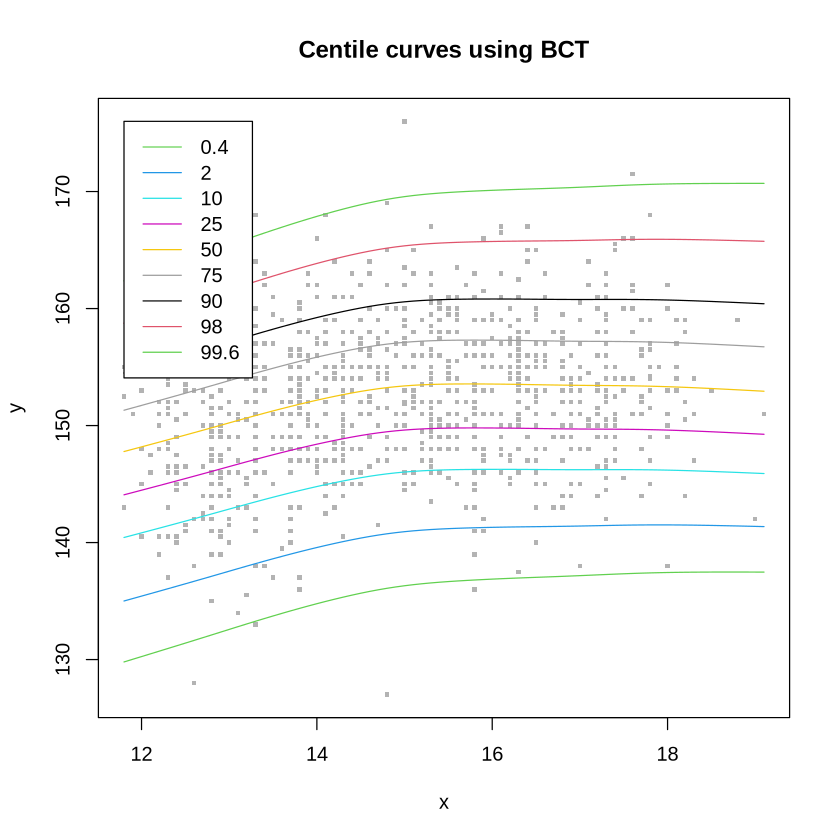

In [105]:
centiles(m_tb4)

Kurva persentil yang dihasilkan menunjukkan bahwa seluruh centile, mulai dari 0.4 hingga 99.6, terbentuk secara halus tanpa adanya gelombang tajam, khususnya pada rentang usia 14–15 tahun yang sebelumnya dicurigai bermasalah. Tidak terlihat adanya lonjakan yang tidak wajar. Hal ini menunjukkan bahwa model stabil secara fungsional dan mampu merepresentasikan pola perubahan tinggi badan secara kontinu.

Selain itu, tidak ditemukan adanya crossing antar kurva persentil. Setiap kurva tetap terurut dengan benar, misalnya P98 selalu berada di atas P90, dan P90 selalu berada di atas P75. Keterurutan ini sangat penting dalam kurva pertumbuhan, karena crossing merupakan indikasi kuat bahwa model tidak sesuai. Dalam kasus ini, struktur kurva tetap konsisten dan terjaga.

Dari sisi interpretasi biologis, bentuk kurva juga masuk akal. Seluruh persentil menunjukkan pola kenaikan hingga sekitar usia 15–16 tahun, kemudian mengalami plateau. Pola ini konsisten di semua tingkat persentil dan sesuai dengan fase pertumbuhan remaja perempuan, di mana terjadi peningkatan tinggi badan hingga pertengahan remaja sebelum stabil.

Bagian ekor distribusi juga tidak menunjukkan perilaku yang aneh. Kurva ekstrem (0.4 dan 99.6) tidak tampak terlalu melebar, tidak menunjukkan overshoot, dan tidak mengalami flare berlebihan pada masa pubertas. Hal ini mengindikasikan bahwa distribusi BCT berhasil menstabilkan tail yang sebelumnya terdeteksi bermasalah pada model yang lebih sederhana.

Walaupun uji Q-statistik menunjukkan bahwa Z3 masih signifikan secara statistik, secara praktis kurva persentil tetap stabil, tidak menunjukkan distorsi visual, dan tidak menimbulkan implikasi klinis yang bermasalah. Dengan ukuran sampel yang besar (n = 1010), deviasi yang sangat kecil sekalipun dapat menghasilkan p-value yang signifikan, meskipun tidak memiliki dampak praktis yang berarti terhadap bentuk kurva.

Berdasarkan keseluruhan evaluasi, model m_tb4 (BCT dengan ν dimodelkan sebagai fungsi smooth terhadap umur) sudah layak digunakan sebagai model akhir untuk tinggi badan. Penambahan kompleksitas lebih lanjut kemungkinan hanya akan menurunkan p-value secara marginal tanpa memberikan perbaikan nyata pada kurva, serta berisiko menimbulkan overfitting.

Dalam pemodelan kurva pertumbuhan, yang dioptimalkan adalah keseimbangan antara kecocokan statistik, stabilitas kurva, interpretasi biologis, dan prinsip parsimony. Model saat ini telah memenuhi keempat aspek tersebut.

Sebagai kesimpulan, untuk BMI distribusi BCCG sudah memadai, sedangkan untuk tinggi badan distribusi BCT dengan parameter skewness yang dimodelkan secara smooth sudah cukup. Model akhir yang diperoleh dapat dipertanggungjawabkan secara statistik maupun substantif.


% of cases below  0.4 centile is  0.8910891 
% of cases below  2 centile is  2.079208 
% of cases below  10 centile is  10.29703 
% of cases below  25 centile is  23.66337 
% of cases below  50 centile is  49.40594 
% of cases below  75 centile is  76.13861 
% of cases below  90 centile is  90.39604 
% of cases below  98 centile is  98.0198 
% of cases below  99.6 centile is  99.50495 


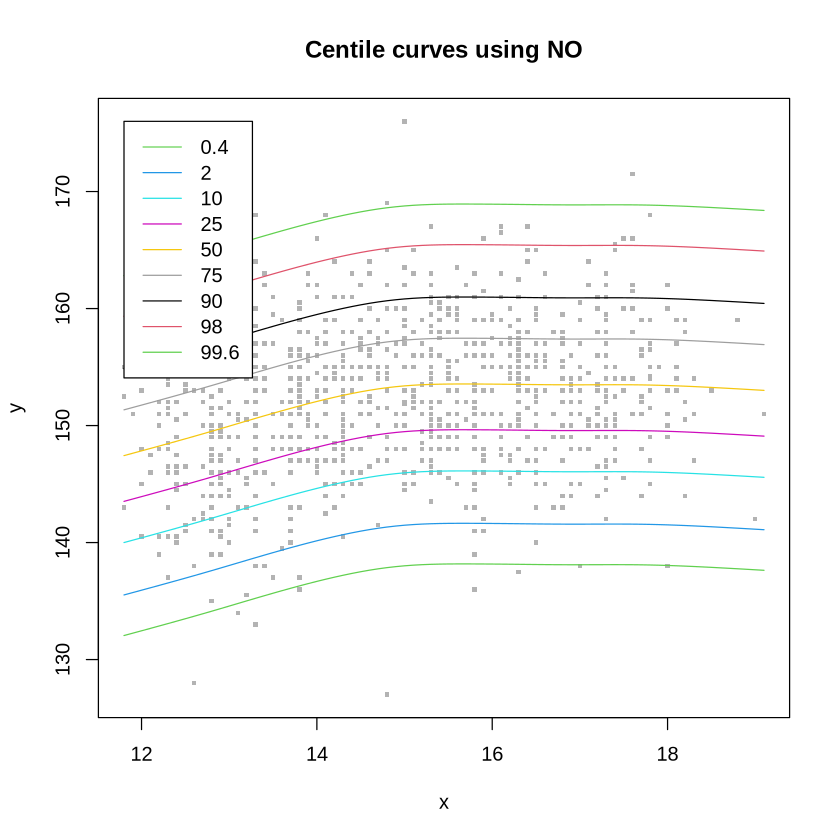

In [96]:
centiles(m_tb)

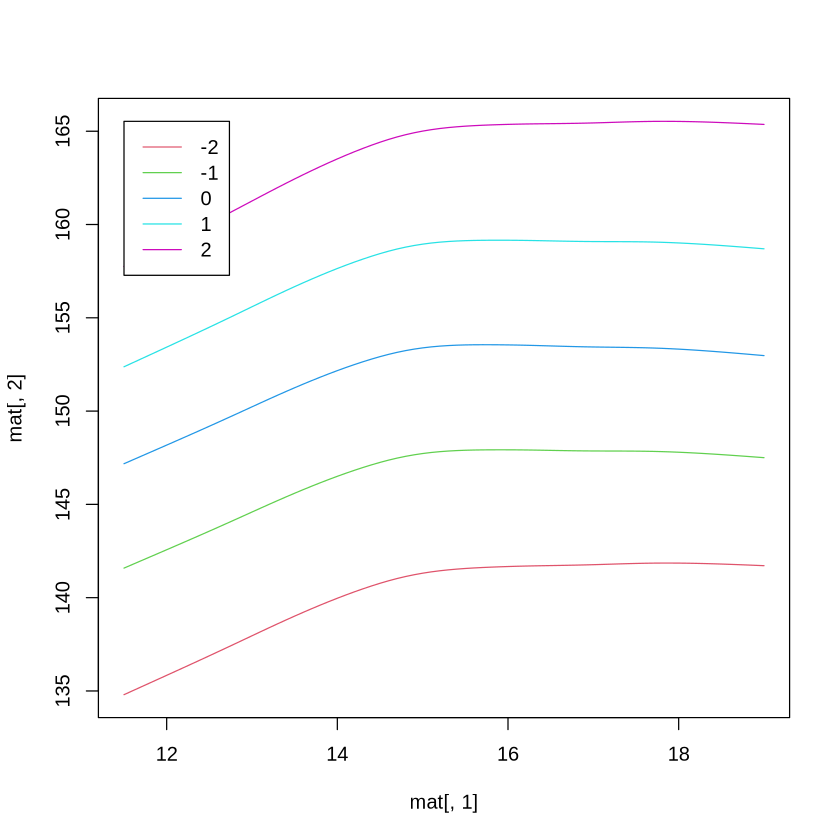

In [116]:
Z_scores <- c(-2, -1, 0, 1, 2)

seq_umur <- seq(from=11.5, to=19, by=0.1)

# prediksi z-score
zscore_tb_female <- centiles.pred(
    obj=m_tb4,
    xname="umur",
    xvalues=seq_umur,
    type="standard-centiles",
    dev = Z_scores,
    plot=TRUE)

In [118]:
tb_df_female <- as.data.frame(zscore_tb_female)
colnames(tb_df_female) <- c("umur", paste0("Z", Z_scores))

tb_female_long  <- tb_df_female %>%
  pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
  mutate(Source="local_tb_female")

tb_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,134.8010,local_tb_female
11.5,Z-1,141.5846,local_tb_female
11.5,Z0,147.1799,local_tb_female
11.5,Z1,152.3754,local_tb_female
11.5,Z2,157.7507,local_tb_female
11.6,Z-2,135.0084,local_tb_female
11.6,Z-1,141.7813,local_tb_female
11.6,Z0,147.3793,local_tb_female
11.6,Z1,152.5857,local_tb_female


In [120]:
write_xlsx(tb_female_long, "zscore_tb_female.xlsx")

In [121]:
who_female_tb <- read_excel("/home/okta/Documents/data-analysis/doni/female/hfa-girls-z-who-2007-exp.xlsx")
who_female_tb

Month,L,M,S,StDev,SD5neg,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
61,1,109.6016,0.04355,4.7731,85.736,90.509,95.282,100.055,104.828,109.602,114.375,119.148,123.921,128.694
62,1,110.1258,0.04364,4.8059,86.096,90.902,95.708,100.514,105.320,110.126,114.932,119.738,124.543,129.349
63,1,110.6451,0.04373,4.8385,86.453,91.291,96.130,100.968,105.807,110.645,115.484,120.322,125.161,129.999
64,1,111.1596,0.04382,4.8710,86.805,91.676,96.547,101.418,106.289,111.160,116.031,120.902,125.773,130.644
65,1,111.6696,0.04390,4.9023,87.158,92.060,96.963,101.865,106.767,111.670,116.572,121.474,126.376,131.279
66,1,112.1753,0.04399,4.9346,87.502,92.437,97.372,102.306,107.241,112.175,117.110,122.044,126.979,131.914
67,1,112.6767,0.04407,4.9657,87.848,92.814,97.780,102.745,107.711,112.677,117.642,122.608,127.574,132.539
68,1,113.1740,0.04415,4.9966,88.191,93.187,98.184,103.181,108.177,113.174,118.171,123.167,128.164,133.161
69,1,113.6672,0.04423,5.0275,88.530,93.557,98.585,103.612,108.640,113.667,118.695,123.722,128.750,133.777


In [122]:
# Pilih kolom yang akan digunakan dan ubah nama kolom agar konsisten
who_tb_female <- who_female_tb %>%
     select(Month, SD2neg, SD1neg, SD0, SD1, SD2) %>%
     rename(
         'umur' = Month,
         'Z-2' = SD2neg,
         'Z-1' = SD1neg,
         'Z0' = SD0,
         'Z1' = SD1,
         'Z2' = SD2
         )

# Ubah format data menjadi long
who_tb_female_long <- who_tb_female %>%
     pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
     mutate(Source="WHO_tb_female")

who_tb_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
61,Z-2,100.055,WHO_tb_female
61,Z-1,104.828,WHO_tb_female
61,Z0,109.602,WHO_tb_female
61,Z1,114.375,WHO_tb_female
61,Z2,119.148,WHO_tb_female
62,Z-2,100.514,WHO_tb_female
62,Z-1,105.320,WHO_tb_female
62,Z0,110.126,WHO_tb_female
62,Z1,114.932,WHO_tb_female


In [123]:
who_tb_female_long$umur<-who_tb_female_long$umur/12

In [124]:
who_tb_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
5.083333,Z-2,100.055,WHO_tb_female
5.083333,Z-1,104.828,WHO_tb_female
5.083333,Z0,109.602,WHO_tb_female
5.083333,Z1,114.375,WHO_tb_female
5.083333,Z2,119.148,WHO_tb_female
5.166667,Z-2,100.514,WHO_tb_female
5.166667,Z-1,105.320,WHO_tb_female
5.166667,Z0,110.126,WHO_tb_female
5.166667,Z1,114.932,WHO_tb_female


In [125]:
who_tb_female_long$umur <- round(who_tb_female_long$umur, 2)
who_tb_female_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
5.08,Z-2,100.055,WHO_tb_female
5.08,Z-1,104.828,WHO_tb_female
5.08,Z0,109.602,WHO_tb_female
5.08,Z1,114.375,WHO_tb_female
5.08,Z2,119.148,WHO_tb_female
5.17,Z-2,100.514,WHO_tb_female
5.17,Z-1,105.320,WHO_tb_female
5.17,Z0,110.126,WHO_tb_female
5.17,Z1,114.932,WHO_tb_female


In [126]:
# filter
who_female_tb1219 <- who_tb_female_long %>%
  filter(umur >= 11.5, umur <= 19)

In [127]:
who_female_tb1219

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.50,Z-2,134.675,WHO_tb_female
11.50,Z-1,141.428,WHO_tb_female
11.50,Z0,148.180,WHO_tb_female
11.50,Z1,154.933,WHO_tb_female
11.50,Z2,161.686,WHO_tb_female
11.58,Z-2,135.164,WHO_tb_female
11.58,Z-1,141.933,WHO_tb_female
11.58,Z0,148.702,WHO_tb_female
11.58,Z1,155.471,WHO_tb_female


In [128]:
write_xlsx(who_tb_female_long, "who_tb_female1219.xlsx")

In [130]:
female_tb_gabungan1219 <- bind_rows(tb_female_long, who_female_tb1219)

In [131]:
female_tb_gabungan1219

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,134.8010,local_tb_female
11.5,Z-1,141.5846,local_tb_female
11.5,Z0,147.1799,local_tb_female
11.5,Z1,152.3754,local_tb_female
11.5,Z2,157.7507,local_tb_female
11.6,Z-2,135.0084,local_tb_female
11.6,Z-1,141.7813,local_tb_female
11.6,Z0,147.3793,local_tb_female
11.6,Z1,152.5857,local_tb_female


In [132]:
write_xlsx(female_tb_gabungan1219, "female_tb_gabungan1219.xlsx")